# Bayesian Inference for Systems of Elementary Reactions

This notebook runs Bayesian parameter inference on an enzyme kinetics ODE model and generates diagnostic plots. It is **Step 2 of 2** — run `guided_solver_config_builder.ipynb` first to generate the required `solver_params.json` configuration file.

---
*Annette Thompson · Fox and Shirts Labs, CU Boulder · 2026 · Developed with assistance from GitHub Copilot (Claude Sonnet 4.6)*

## Import Libraries

In [10]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "../Utilities")

from pathlib import Path
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import preliz as pz

from effective_parameter_limits import evaluate_effective_parameter_limits
from experiment_framework import load_experiment_bundle
from inference_runner import (
    get_free_parameter_names,
    import_solver_params,
    run_bayesian_inference,
    summarize_inference_metrics,
 )
from inference_plotting import (
    plot_diffusion_feasible_parameter_family,
    plot_diffusion_feasible_parameter_marginals,
    plot_inference_diagnostics,
)
from reaction_model_builder import build_ode_system_from_reactions

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Step 2: Configure and Run

Set the key variables below, then run this cell.

| Variable | Value | Effect |
|---|---|---|
| `use_existing_results` | `False` | **Run full inference** — samples prior then posterior (~10–30 min depending on hardware) |
| `use_existing_results` | `True` | **Load saved results** — skips sampling and goes straight to plotting (requires a previous run) |
| `folder_name` | `"FabD kon inference"` | Folder used to find the solver JSON and organize reactions, data, calculation files, and results |

> **Paths:** The solver params JSON sets `path_base` to the Python Model home directory. Reaction, data, calculation-module, and output paths are stored relative to that home directory.


=== Run Status ===
Loaded existing posterior samples (inference run skipped).

=== Files ===
- Prior samples: /Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Python Model/Results/Test FabD FabH - a1 c1/prior_samples_pm.nc
- Posterior samples: /Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Python Model/Results/Test FabD FabH - a1 c1/posterior_samples_pm.nc

=== Posterior Summary ===


/Users/annettethompson/anaconda3/envs/Bayesian/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.66 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a1,2.1247,0.2431,1.7780,2.5058,131.3866,126.9545,1.0362,0.0213,0.0161
c1,4.6742,1.1270,3.1716,6.4694,133.7602,135.6976,1.0356,0.0988,0.0904



=== Model Comparison ===
LOO
Computed from 800 posterior samples and 21 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   118.01    11.31
p_loo        6.07        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.66]   (good)       20   95.2%
   (0.66, 1]   (bad)         0    0.0%
    (1, Inf)   (very bad)    1    4.8%


=== Saved Plots ===
- Trace diagnostics: /Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Python Model/Results/Test FabD FabH - a1 c1/trace_plot.png
- Posterior marginals: /Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Python Model/Results/Test FabD FabH - a1 c1/trace_plot_hist.pdf
- Prior marginals: /Users/annettethompson/Lib

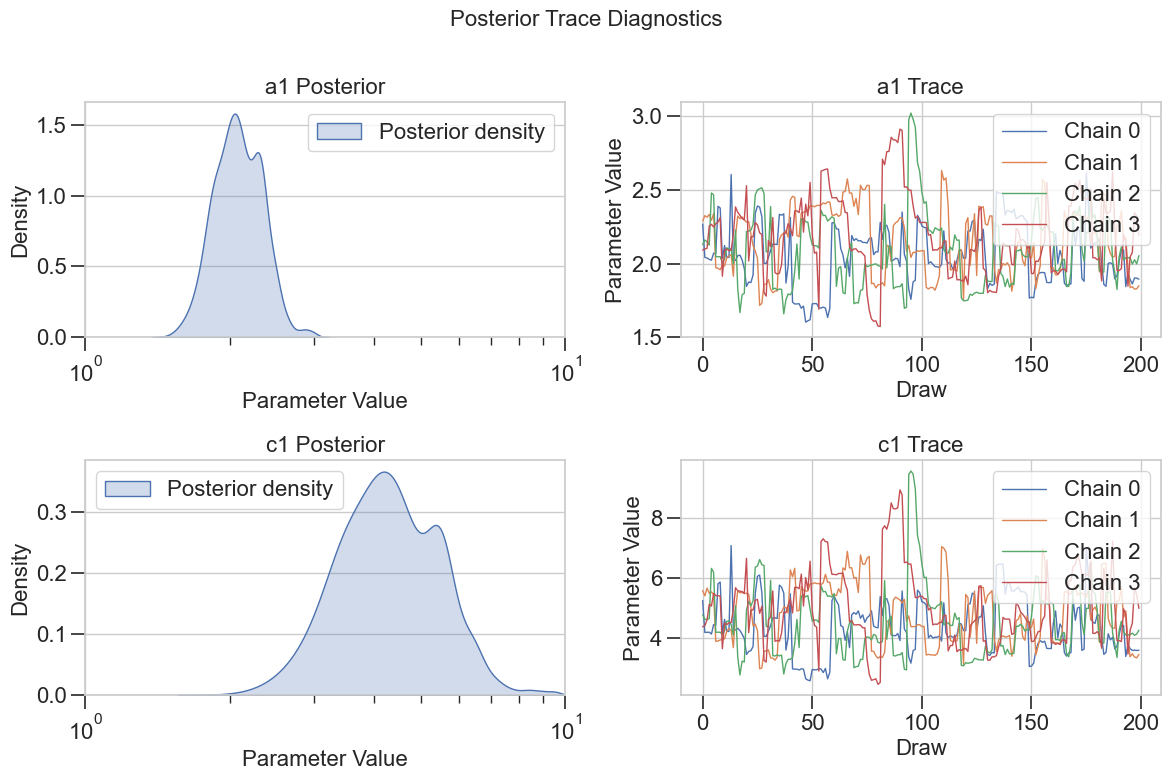

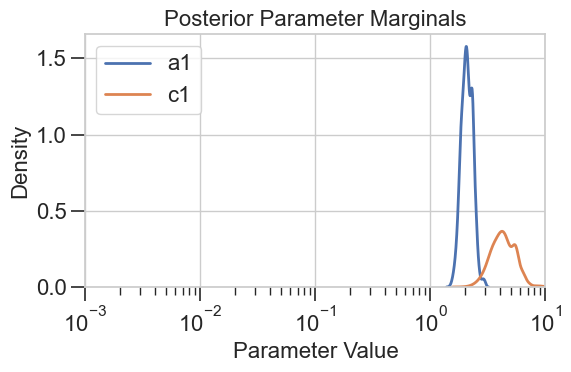

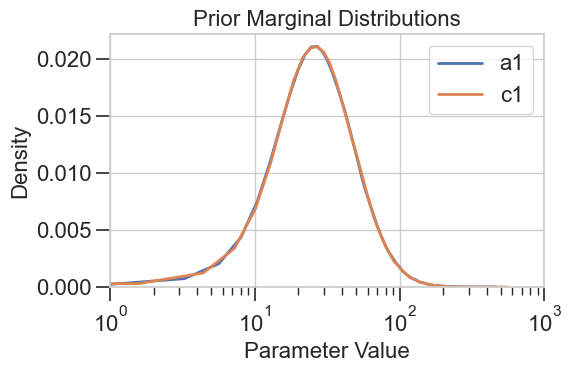

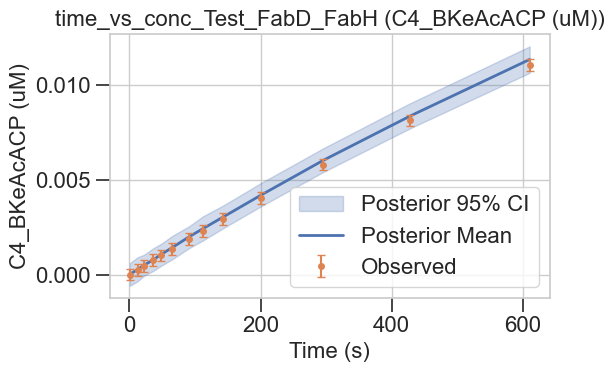

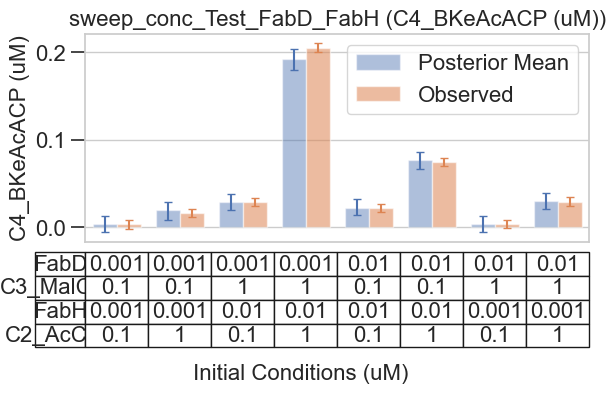

In [21]:
folder_name = "Test FabD FabH - a1 c1"

# Toggle workflow mode:
use_existing_results = True
use_log_param_axis = True

# Plot styling
plt.style.use("default")

solver_params_file = f"solver_params.json"
solver_param_path = Path(f"../Results/{folder_name}/{solver_params_file}")
imported_solver_params = import_solver_params(solver_param_path)
solver_params = imported_solver_params.solver_params
output_paths = imported_solver_params.output_paths

def print_section(title):
    print(f"\n=== {title} ===")

def print_item(label, value):
    print(f"- {label}: {value}")

if "trace_plot_file" not in output_paths:
    raise KeyError("Missing output_paths key: trace_plot_file")

reactions_source = imported_solver_params.reactions_source
results_save_dir = imported_solver_params.results_save_dir
prior_samples_file = imported_solver_params.prior_samples_file
posterior_samples_file = imported_solver_params.posterior_samples_file
trace_plot_file = output_paths["trace_plot_file"]

# Ensure output directory exists before writing any results
results_save_dir.mkdir(parents=True, exist_ok=True)

prior_file_path = results_save_dir / prior_samples_file
posterior_file_path = results_save_dir / posterior_samples_file
trace_path = results_save_dir / trace_plot_file

if not use_existing_results:
    result = run_bayesian_inference(solver_param_path)

    inference_data = result.posterior
    experiment_for_plots = result.experiment
    free_params = result.free_params
    summary_table = result.summary
    loo_result = result.loo

    experiment_summary_text = result.experiment_summary
    prior_path_text = result.prior_file
    results_path_text = result.results_file
    trace_path_text = str(trace_path)
else:
    if not posterior_file_path.exists():
        raise FileNotFoundError(
            f"Posterior samples file not found: {posterior_file_path}. Set use_existing_results=False to run inference first."
        )

    inference_data = az.from_netcdf(posterior_file_path)

    _, species_names_for_experiment, _, _, _ = build_ode_system_from_reactions(reactions_source)
    experiment_for_plots = load_experiment_bundle(
        solver_params=solver_params,
        solver_params_file=str(solver_param_path),
        species_names=species_names_for_experiment,
    )

    free_params = get_free_parameter_names(solver_params)
    metrics = summarize_inference_metrics(inference_data, free_params)
    free_params = metrics["free_params"]
    summary_table = metrics["summary"]
    loo_result = metrics["loo"]

    experiment_summary_text = "Loaded existing posterior samples (inference run skipped)."
    prior_path_text = str(prior_file_path) if prior_file_path.exists() else "Not found"
    results_path_text = str(posterior_file_path)
    trace_path_text = str(trace_path)

print_section("Run Status")
print(experiment_summary_text)

print_section("Files")
print_item("Prior samples", prior_path_text)
print_item("Posterior samples", results_path_text)

print_section("Posterior Summary")
display(summary_table)

print_section("Model Comparison")
print("LOO")
print(loo_result)

diagnostic_artifacts = plot_inference_diagnostics(
    inf_data=inference_data,
    free_params=free_params,
    experiment=experiment_for_plots,
    save_path=trace_path_text,
    include_tuning_in_trace=True,
    posterior_start_line=True,
    show=True,
    use_log_param_axis=use_log_param_axis,
 )
trace_artifacts = diagnostic_artifacts["trace_diagnostics"]
parameter_marginal_artifacts = diagnostic_artifacts["parameter_marginals"]
prior_marginal_artifacts = diagnostic_artifacts["prior_marginals"]
predictive_artifacts = diagnostic_artifacts["predictive"]

print_section("Saved Plots")
if trace_artifacts.get("plot_file"):
    print_item("Trace diagnostics", trace_artifacts["plot_file"])
if parameter_marginal_artifacts.get("plot_file"):
    print_item("Posterior marginals", parameter_marginal_artifacts["plot_file"])
if prior_marginal_artifacts.get("plot_file"):
    print_item("Prior marginals", prior_marginal_artifacts["plot_file"])
elif not prior_marginal_artifacts.get("prior_var_names"):
    print("- Prior marginals: no matching prior variables found")

if predictive_artifacts.get("data_vs_results_plot_files"):
    print_item("Predictive plot count", len(predictive_artifacts["data_vs_results_plot_files"]))
    for dataset_name, plot_path in predictive_artifacts["data_vs_results_plot_files"].items():
        print_item(dataset_name, plot_path)

plot_artifacts = {
    "trace_diagnostics": trace_artifacts,
    "parameter_marginals": parameter_marginal_artifacts,
    "prior_marginals": prior_marginal_artifacts,
    "predictive": predictive_artifacts,
}

---
## Step 3: Diffusion-Limited Effective Parameter Diagnostics

Define effective-parameter limit rules, then evaluate them against the posterior samples already in `inference_data`.

This step is independent of sampling: after changing the limits or patterns below, rerun this cell only. It works with both fresh inference results and `use_existing_results=True`.


=== Diffusion Feasibility ===
- Feasible posterior draws: 800/800 (100.0%)

=== Limited Effective-Parameter Summary ===


,rule_name,rxn_name,direction,param_name,reactants,scale_expr,scale_param_names,lower,upper,n_draws,n_violations,violation_fraction,min_effective,median_effective,max_effective
2,protein_protein_diffusion_limit,C2_FabH_Act_binding_MalACP,fwd,kon_H_Act_MalACP,C2_FabH_Act + C3_MalACP,NaN,,-inf,629.0,800,0,0.0,618.335961,618.335961,618.335961
0,protein_ligand_diffusion_limit,FabD_binding_MalCoA,fwd,kon_D_MalCoA,FabD + C3_MalCoA,NaN,,-inf,1650.0,800,0,0.0,189.964965,189.964965,189.964965
1,protein_protein_diffusion_limit,FabD_Act_binding_ACP,fwd,kon_D_Act_ACP,C3_FabD_Act + ACP,NaN,,-inf,629.0,800,0,0.0,77.291995,77.291995,77.291995
3,protein_protein_diffusion_limit,C4_FabH_inhibition_by_AcACP,fwd,kon_H_AcACP,FabH + C4_AcACP,NaN,,-inf,629.0,800,0,0.0,0.308800,0.308800,0.308800
4,protein_protein_diffusion_limit,C6_FabH_inhibition_by_AcACP,fwd,kon_H_AcACP,FabH + C6_AcACP,NaN,,-inf,629.0,800,0,0.0,0.308800,0.308800,0.308800
5,protein_protein_diffusion_limit,C8_FabH_inhibition_by_AcACP,fwd,kon_H_AcACP,FabH + C8_AcACP,NaN,,-inf,629.0,800,0,0.0,0.308800,0.308800,0.308800
6,protein_protein_diffusion_limit,C10_FabH_inhibition_by_AcACP,fwd,kon_H_AcACP,FabH + C10_AcACP,NaN,,-inf,629.0,800,0,0.0,0.308800,0.308800,0.308800
7,protein_protein_diffusion_limit,C12_FabH_inhibition_by_AcACP,fwd,kon_H_AcACP,FabH + C12_AcACP,NaN,,-inf,629.0,800,0,0.0,0.308800,0.308800,0.308800
8,protein_protein_diffusion_limit,C14_FabH_inhibition_by_AcACP,fwd,kon_H_AcACP,FabH + C14_AcACP,NaN,,-inf,629.0,800,0,0.0,0.308800,0.308800,0.308800
9,protein_protein_diffusion_limit,C16_FabH_inhibition_by_AcACP,fwd,kon_H_AcACP,FabH + C16_AcACP,NaN,,-inf,629.0,800,0,0.0,0.308800,0.308800,0.308800



=== Posterior Draw Feasibility Summary ===


,draw_index,is_feasible,n_violations,max_violation_ratio,worst_channel,worst_rule
0,0,True,0,0.0,None,None
1,1,True,0,0.0,None,None
2,2,True,0,0.0,None,None
3,3,True,0,0.0,None,None
4,4,True,0,0.0,None,None
5,5,True,0,0.0,None,None
6,6,True,0,0.0,None,None
7,7,True,0,0.0,None,None
8,8,True,0,0.0,None,None
9,9,True,0,0.0,None,None



=== Saved Diffusion Diagnostic Plots ===
- Feasible area marginals: /Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Python Model/Results/Test FabD FabH - a1 c1/trace_plot_diffusion_feasible_marginals.pdf
- Feasible parameter family: /Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Python Model/Results/Test FabD FabH - a1 c1/trace_plot_diffusion_feasible_family.pdf


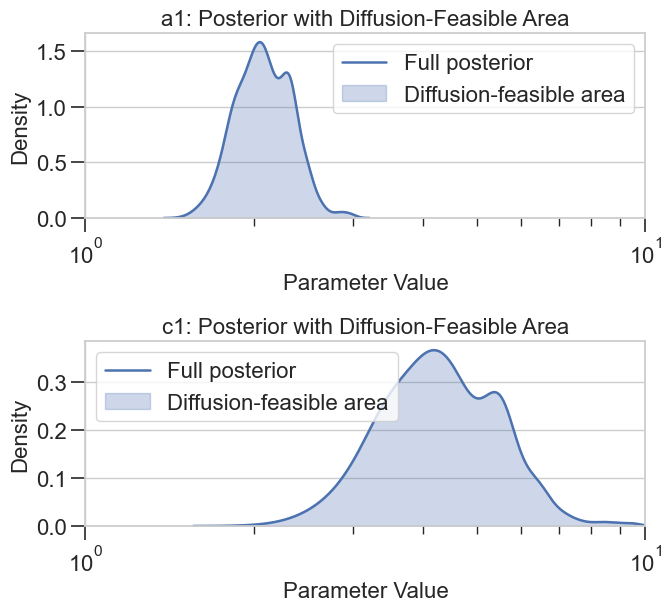

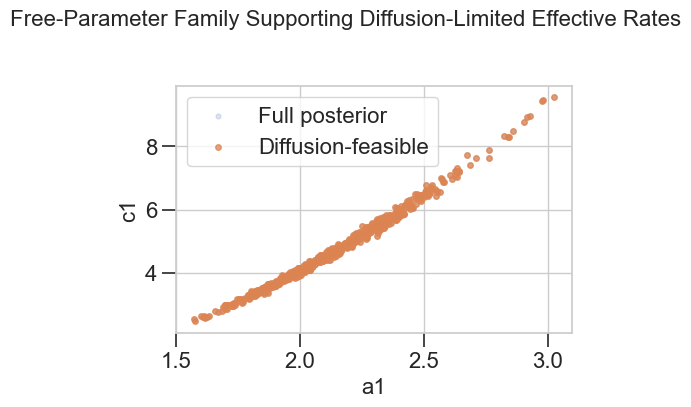

In [18]:
# Edit these rules and rerun this cell to recompute diffusion-limit feasibility.
# Rules are applied to final effective values after scaling: base_parameter * scaling_expression(theta).

protein_pattern = r"Fab[A-Z]|TesA|ACP"
kon_name_pattern = r"(^kon|_k_on_)"

effective_parameter_limits = [
    {
        "name": "protein_protein_diffusion_limit",
        "param_name_pattern": kon_name_pattern,
        "reactant_name_patterns": [protein_pattern],
        "reactant_match_count": 2,
        "upper": 629.0,
    },
    {
        "name": "protein_ligand_diffusion_limit",
        "param_name_pattern": kon_name_pattern,
        "reactant_name_patterns": [protein_pattern],
        "reactant_match_count": 1,
        "upper": 1650.0,
    },
    # Exact base-parameter example:
    # {"name": "specific_param_limit", "param_names": ["some_k_on_param"], "lower": 0.0, "upper": 1650.0},
    # Exact scaling-parameter example: checks effective values for every channel whose scale expression uses a1.
    # {"name": "a1_scaled_effective_limit", "param_names": ["a1"], "upper": 1650.0},
    # Scaling-parameter pattern example:
    # {"name": "a_family_scaled_effective_limit", "scaling_param_name_pattern": "^a", "upper": 1650.0},
]

diffusion_limit_result = evaluate_effective_parameter_limits(
    inf_data=inference_data,
    reactions_source=reactions_source,
    free_params=free_params,
    effective_parameter_limits=effective_parameter_limits,
)
diffusion_feasibility_mask = diffusion_limit_result.feasibility_mask

feasible_count = int(np.sum(diffusion_feasibility_mask))
total_count = int(diffusion_feasibility_mask.size)
print_section("Diffusion Feasibility")
print_item("Feasible posterior draws", f"{feasible_count}/{total_count} ({feasible_count / total_count:.1%})")

if diffusion_limit_result.channel_summary.empty:
    print("- Limited effective-parameter summary: no matching reaction channels")
else:
    print_section("Limited Effective-Parameter Summary")
    display(
        diffusion_limit_result.channel_summary.sort_values(
            ["violation_fraction", "max_effective"],
            ascending=[False, False],
        )
    )

print_section("Posterior Draw Feasibility Summary")
display(diffusion_limit_result.draw_summary.head(20))

diffusion_marginal_path = trace_path.with_name(f"{trace_path.stem}_diffusion_feasible_marginals.pdf")
diffusion_family_path = trace_path.with_name(f"{trace_path.stem}_diffusion_feasible_family.pdf")

diffusion_marginal_artifacts = plot_diffusion_feasible_parameter_marginals(
    inf_data=inference_data,
    free_params=free_params,
    feasibility_mask=diffusion_feasibility_mask,
    save_file=str(diffusion_marginal_path),
    show=True,
    use_log_param_axis=use_log_param_axis,
)
diffusion_family_artifacts = plot_diffusion_feasible_parameter_family(
    inf_data=inference_data,
    free_params=free_params,
    feasibility_mask=diffusion_feasibility_mask,
    save_file=str(diffusion_family_path),
    show=True,
)

plot_artifacts["diffusion_feasible_marginals"] = diffusion_marginal_artifacts
plot_artifacts["diffusion_feasible_family"] = diffusion_family_artifacts

print_section("Saved Diffusion Diagnostic Plots")
if diffusion_marginal_artifacts.get("plot_file"):
    print_item("Feasible area marginals", diffusion_marginal_artifacts["plot_file"])
if diffusion_family_artifacts.get("plot_file"):
    print_item("Feasible parameter family", diffusion_family_artifacts["plot_file"])

---
## Step 4: Visualize Prior Distributions

The next cells plot the **prior distributions** for each free parameter — these represent your beliefs about plausible parameter values *before* seeing the data. Compare these to the posterior marginals generated above to see how much the data updated your beliefs.

Each prior is shaped by the `lower`/`upper` bounds and mass % (default 95%) you set in the config builder. The distribution is chosen automatically via maximum entropy (`preliz.maxent`).

Bounds are read directly from `solver_params` so these plots always stay in sync with your config.

/var/folders/41/tc0sn5mn46g26bhzv3slfbd80000gn/T/ipykernel_82456/3599245655.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(ax.get_xticks(), 2), fontsize=18)


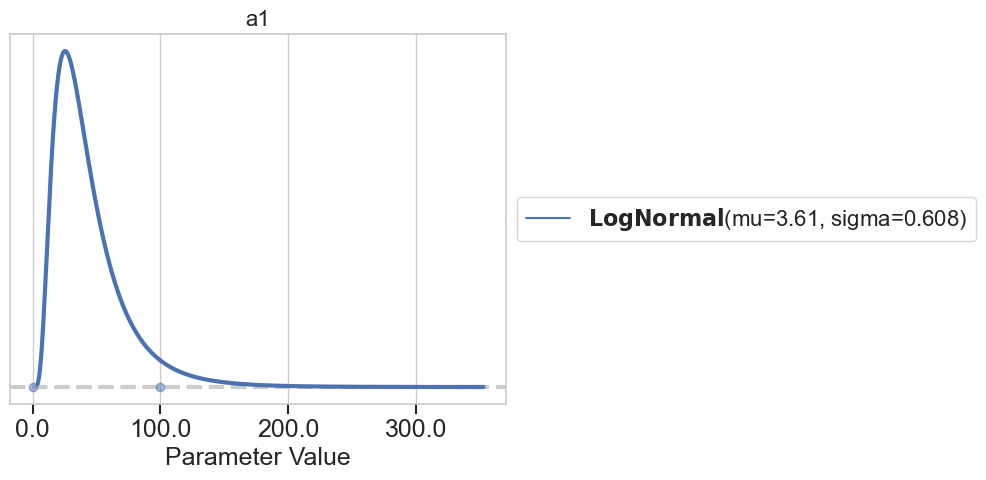

/var/folders/41/tc0sn5mn46g26bhzv3slfbd80000gn/T/ipykernel_82456/3599245655.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(ax.get_xticks(), 2), fontsize=18)


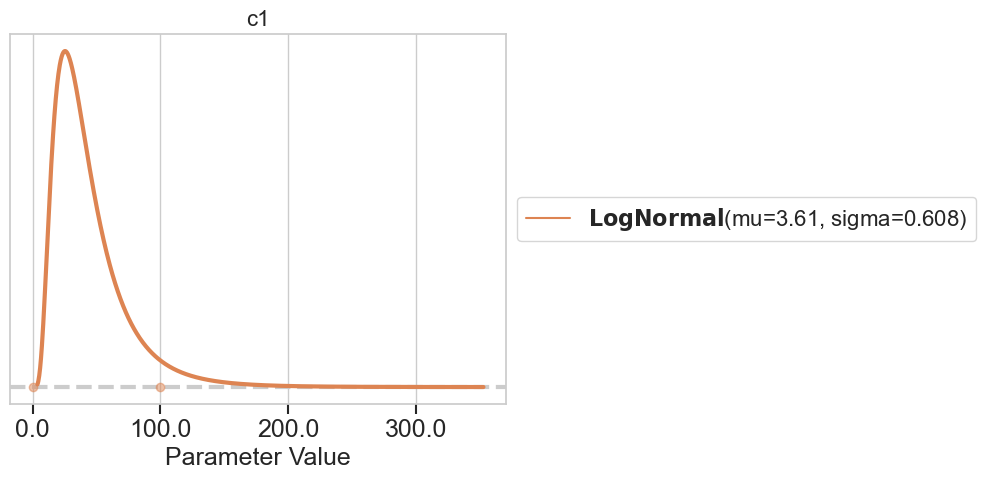

In [19]:
colors = ["C0", "C1", "C2", "C3", "C4"]

for i, param_spec in enumerate(solver_params["free_kinetic_params"]):
    prior_p = param_spec["prior_dist_params"]
    dist = getattr(pz, prior_p["distribution"])()
    result = pz.maxent(
        dist,
        lower=prior_p["lower"],
        upper=prior_p["upper"],
        mass=prior_p.get("mass", 0.95),
        plot=True,
        plot_kwargs={"color": colors[i % len(colors)]},
    )
    ax = plt.gca()
    for line in ax.lines:
        line.set_linewidth(3)
    ax.tick_params(width=1.5, length=7)
    ax.set_xlabel("Parameter Value", fontsize=18)
    ax.set_xticklabels(np.round(ax.get_xticks(), 2), fontsize=18)
    ax.set_title(param_spec["param_name"], fontsize=16)
    plt.show()